<div style="padding:10px; 
            color:black;
            margin:10px;
            font-size:150%;
            display:fill;
            border-radius:1px;
            border-style: solid;
            border-color:black;
            background-color:gold;
            overflow:hidden;">
    <center>
        <a id='top'></a>
        <b style="color:black">Not my code.... Table of Contents</b>
    </center>
    <br>
    <ul>
        <li>
            <a href="#1" style="color:black">1 - Imports</a>
        </li>
        <li>
            <a href="#2" style="color:black">2 - Data Preprocessing</a>
            <ul>
                <li>
                    <a href="#2-1" style="color:black">2.1 - Create Directories</a>
                </li>
                <li>
                    <a href="#2-2" style="color:black">2.2 - Creating Generators</a>
                </li>
            </ul>
        </li>
        <li>
            <a href="#3" style="color:black">3 - Model Implementation</a>
        </li>
        <li>
            <a href="#4" style="color:black">4 - Evaluation</a>
            <ul>
                <li>
                    <a href="#4-1" style="color:black">4.1 - Evaluation on Test Set</a>
                </li>
                <li>
                    <a href="#4-2" style="color:black">4.2 - Visualizing  Predictions</a>
                </li>
                <li>
<a href="#4-3" style="color:black">4.3 - Visualizing Activation Maps</a>
</li>
<li>
<a href="#4-4" style="color:black">4.4 - Visualizing Training Process</a>
</li>
</ul>
</li>
<li>
<a href="#5" style="color:black">5 - Trying Data Augmentation</a>
</li>
<li>
<a href="#6" style="color:black">6 - Conclusion</a>
</li>
<li>
<a href="#7" style="color:black">7 - Thank You</a>
</li>
</ul>

</div>


<a id="1"></a>
<h1 style='background:#FFD700;border:0; color:black;
    box-shadow: 10px 10px 5px 0px rgba(0,0,0,0.75);
    transform: rotateX(10deg);
    '><center style='color: black;'>Imports</center></h1>




# Imports

In [71]:
#!pip install anylabeling

In [72]:
!pip install plotly -q

In [73]:
!pip install tensorflow keras --upgrade -q

In [128]:
import os
import shutil
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import random
import plotly.express as px
import scipy as sp
import itertools

from scipy import ndimage
from shutil import copyfile, rmtree
import tensorflow as tf
from tensorflow.keras.layers import Conv2D,Add,MaxPooling2D, Dense, BatchNormalization,Input, Dropout, AveragePooling2D, Flatten
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import LearningRateScheduler
from tensorflow.keras.preprocessing.image import ImageDataGenerator 


In [129]:
!pip install kagglehub -q

In [139]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("meetnagadia/malaria-dataset")

print("Path to dataset files:", path)

100%|██████████| 6.18M/6.18M [00:01<00:00, 5.27MB/s]

Extracting files...
Path to dataset files: /home/arulipn/.cache/kagglehub/datasets/meetnagadia/malaria-dataset/versions/1


In [142]:
!ls -al '/home/arulipn/.cache/kagglehub/datasets/meetnagadia/malaria-dataset/versions/1/Dataset/Train'

total 52
drwxr-sr-x 4 arulipn users  4096 Mar 12 08:34 .
drwxr-sr-x 4 arulipn users  4096 Mar 12 08:34 ..
drwxr-sr-x 2 arulipn users 24576 Mar 12 08:34 Parasite
drwxr-sr-x 2 arulipn users 20480 Mar 12 08:34 Uninfected


<a id="2"></a>
<h1 style='background:#FFD700;border:0; color:black;
    box-shadow: 10px 10px 5px 0px rgba(0,0,0,0.75);
    transform: rotateX(10deg);
    '><center style='color: black;'>Data Preprocessing</center></h1>
    
# Data Preprocessing


**Let's check the distribution of the data**

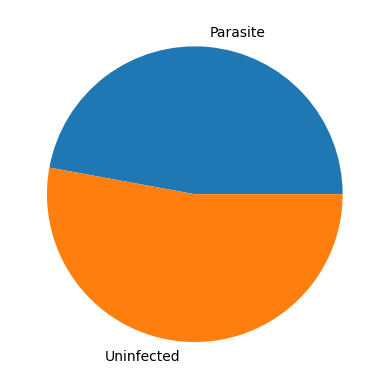

In [144]:
class_names = ['Parasite', 'Uninfected'] 

n_dogs = len(os.listdir('/home/arulipn/.cache/kagglehub/datasets/meetnagadia/malaria-dataset/versions/1/Dataset/Train/Parasite'))
n_cats = len(os.listdir('/home/arulipn/.cache/kagglehub/datasets/meetnagadia/malaria-dataset/versions/1/Dataset/Train/Uninfected'))
n_images = [n_cats, n_dogs]
plt.pie(n_images, labels = class_names)
plt.show() 

<a name="2-1"></a>
## create directories for training and validation

In [148]:
base = "/tmp/malaria"

# Ištrina, jei egzistuoja
shutil.rmtree(base, ignore_errors=True)

In [149]:
try:
    os.mkdir('/tmp/malaria')
    os.mkdir('/tmp/malaria/training')
    os.mkdir('/tmp/malaria/validation')
    os.mkdir('/tmp/malaria/test')
    os.mkdir('/tmp/malaria/training/Parasite')
    os.mkdir('/tmp/malaria/training/Uninfected')
    os.mkdir('/tmp/malaria/validation/Parasite')
    os.mkdir('/tmp/malaria/validation/Uninfected')
    os.mkdir('/tmp/malaria/test/Parasite')
    os.mkdir('/tmp/malaria/test/Uninfected')
except OSError:
    print('Error failed to make directory')

In [150]:
#Define data path
CAT_DIR = '/home/arulipn/.cache/kagglehub/datasets/meetnagadia/malaria-dataset/versions/1/Dataset/Train/Parasite'
DOG_DIR = '/home/arulipn/.cache/kagglehub/datasets/meetnagadia/malaria-dataset/versions/1/Dataset/Train/Uninfected'

TRAINING_DIR = "/tmp/malaria/training/"
VALIDATION_DIR = "/tmp/malaria/validation/"

TRAINING_CATS = os.path.join(TRAINING_DIR, "Parasite/")
VALIDATION_CATS = os.path.join(VALIDATION_DIR, "Parasite/")

TRAINING_DOGS = os.path.join(TRAINING_DIR, "Uninfected/")
VALIDATION_DOGS = os.path.join(VALIDATION_DIR, "Uninfected/")

# Define whether to include test split or not
INCLUDE_TEST = False

In [151]:
print(len(os.listdir('/tmp/malaria/training/Parasite')))
print(len(os.listdir('/tmp/malaria/training/Uninfected')))

print(len(os.listdir('/tmp/malaria/validation/Parasite')))
print(len(os.listdir('/tmp/malaria/validation/Uninfected')))

print(len(os.listdir('/tmp/malaria/test/Parasite')))
print(len(os.listdir('/tmp/malaria/test/Uninfected')))

0
0
0
0
0
0


**Now let's create  a function to split the   data**

In [152]:
def split_data(main_dir, training_dir, validation_dir, test_dir=None, include_test_split = True,  split_size=0.9):
    """
    Splits the data into train validation and test sets (optional)

    Args:
    main_dir (string):  path containing the images
    training_dir (string):  path to be used for training
    validation_dir (string):  path to be used for validation
    test_dir (string):  path to be used for test
    include_test_split (boolen):  whether to include a test split or not
    split_size (float): size of the dataset to be used for training
    """
    files = []
    for file in os.listdir(main_dir):
        if  os.path.getsize(os.path.join(main_dir, file)): # check if the file's size isn't 0
            files.append(file) # appends file name to a list

    shuffled_files = random.sample(files,  len(files)) # shuffles the data
    split = int(0.9 * len(shuffled_files)) #the training split casted into int for numeric rounding
    train = shuffled_files[:split] #training split
    split_valid_test = int(split + (len(shuffled_files)-split)/2)
   
    if include_test_split:
        validation = shuffled_files[split:split_valid_test] # validation split
        test = shuffled_files[split_valid_test:]
    else:
        validation = shuffled_files[split:]

    for element in train:
        copyfile(os.path.join(main_dir,  element), os.path.join(training_dir, element)) # copy files into training directory

    for element in validation:
        copyfile(os.path.join(main_dir,  element), os.path.join(validation_dir, element))# copy files into validation directory
        
    if include_test_split:
        for element in test:
            copyfile(os.path.join(main_dir,  element), os.path.join(test_dir, element)) # copy files into test directory
    print("Split sucessful!")

**Now let's call the function to create the  training/validation data**

In [155]:
split_data(CAT_DIR, '/tmp/malaria/training/Parasite', '/tmp/malaria/validation/Parasite', '/tmp/malaria/test/Parasite',INCLUDE_TEST, 0.9)
split_data(DOG_DIR, '/tmp/malaria/training/Uninfected', '/tmp/malaria/validation/Uninfected','/tmp/malaria/test/Uninfected',INCLUDE_TEST, 0.9)

Split sucessful!
Split sucessful!


**As a sanity check let's check the data directories**

In [159]:
print(len(os.listdir('/tmp/malaria/training/Parasite')))
print(len(os.listdir('/tmp/malaria/training/Uninfected')))

print(len(os.listdir('/tmp/malaria/validation/Parasite')))
print(len(os.listdir('/tmp/malaria/validation/Uninfected')))

#copy predefined test samples
shutil.copytree('/home/arulipn/.cache/kagglehub/datasets/meetnagadia/malaria-dataset/versions/1/Dataset/Test/Parasite', '/tmp/malaria/test/Parasite', dirs_exist_ok=True)
shutil.copytree('/home/arulipn/.cache/kagglehub/datasets/meetnagadia/malaria-dataset/versions/1/Dataset/Test/Uninfected', '/tmp/malaria/test/Uninfected', dirs_exist_ok=True)
print(len(os.listdir('/tmp/malaria/test/Parasite')))
print(len(os.listdir('/tmp/malaria/test/Uninfected')))

198
176
22
20
91
43


<a name="2-2"></a>

## Create Generators

In [160]:
train_gen = ImageDataGenerator(
        rescale=1./255)


validation_gen =  ImageDataGenerator(
        rescale=1./255.)

if INCLUDE_TEST:
    test_gen =  ImageDataGenerator(
            rescale=1./255.)


In [167]:
train_generator = train_gen.flow_from_directory(
        '/tmp/malaria/training',
        target_size=(150, 150),
        batch_size=16,
        class_mode='binary')
validation_generator = validation_gen.flow_from_directory(
        '/tmp/malaria/validation',
        target_size=(150, 150),
        batch_size=16,
        class_mode='binary')

INCLUDE_TEST = 1
if INCLUDE_TEST:
    test_generator = test_gen.flow_from_directory(
        '/tmp/malaria/test',
        target_size=(150, 150),
        batch_size=16,
        class_mode='binary')

Found 374 images belonging to 2 classes.
Found 42 images belonging to 2 classes.
Found 134 images belonging to 2 classes.


**Now let's make sure we got the correct data**

In [168]:
class_names = ['Parasite', 'Uninfected']
def plot_data(generator, n_images=7):
    """
    Plots random data from dataset
    Args:
        generator: a generator instance
        n_images : number of images to plot
    """
    plt.figure(figsize=(10, 10))
    
    # Gauname tik tiek batch'ų, kiek reikia (n_images // batch_size + 1)
    for i in range(n_images):
        # Gauname vieną batch'ą
        images, labels = next(generator)  # arba generator.__next__()
        
        # Paimame pirmą nuotrauką iš batch'o
        img = images[0]
        label = labels[0].argmax() if labels.ndim > 1 else labels[0]  # jei categorical
        
        # Piešiame
        plt.subplot(3, 3, i+1)
        plt.imshow(img)
        plt.title(f"Class: {label}")
        plt.axis('off')
    
    plt.tight_layout()
    plt.show()

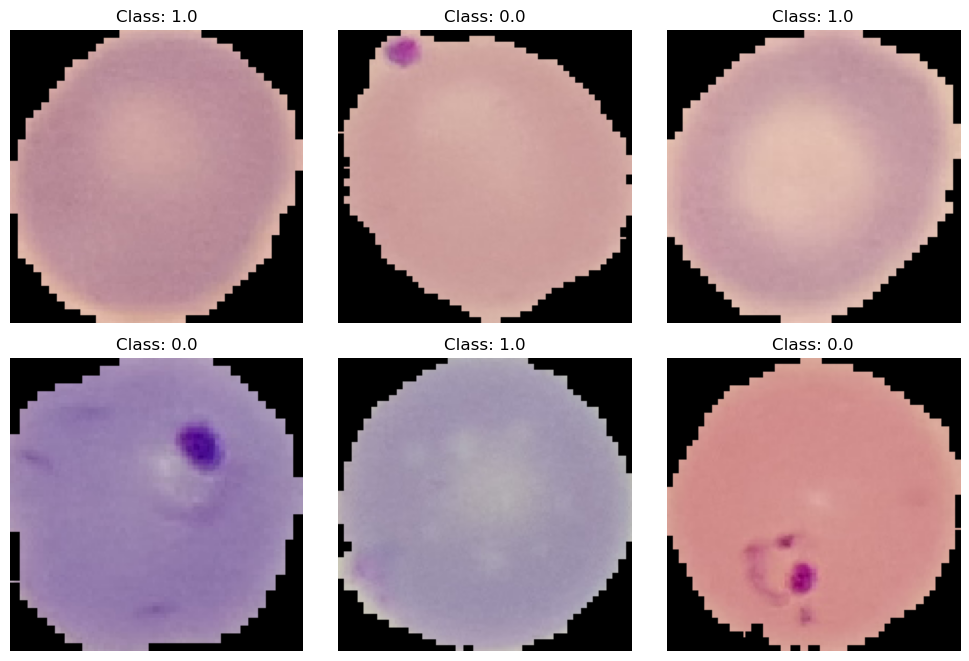

In [169]:
plot_data(train_generator,6)


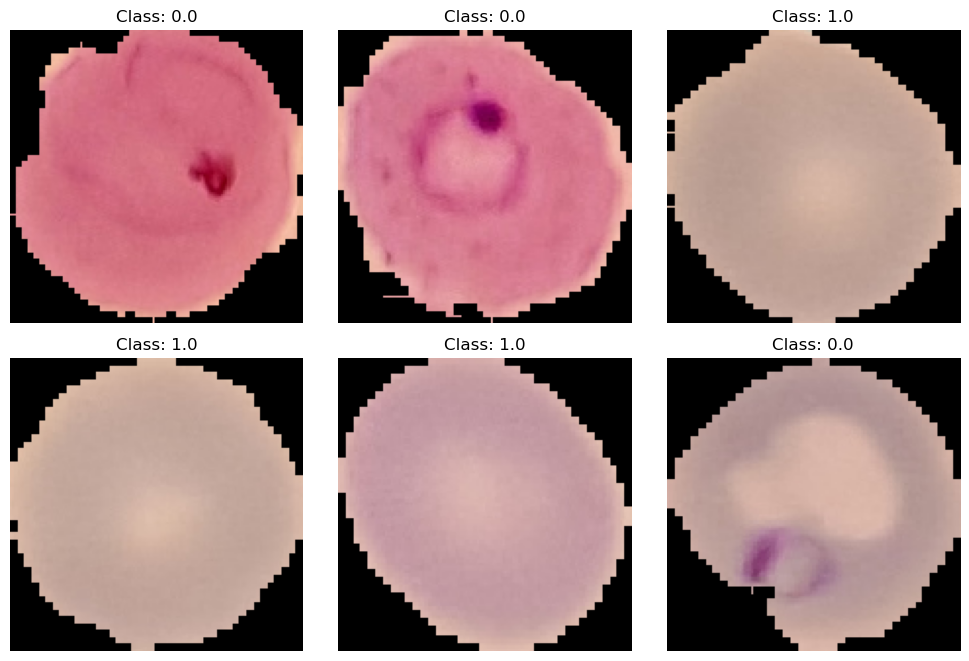

In [170]:
plot_data(validation_generator,6)


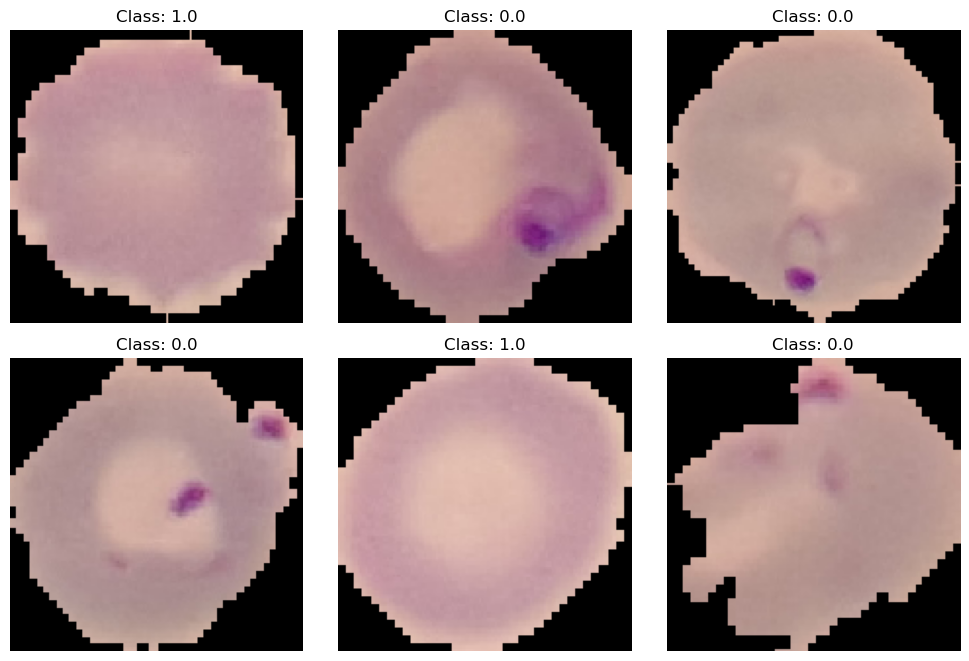

In [171]:
if INCLUDE_TEST:
    plot_data(test_generator, 6)

**Great, now that the data is ready let's train our model**

<a id="3"></a>
<h1 style='background:#FFD700;border:0; color:black;
    box-shadow: 10px 10px 5px 0px rgba(0,0,0,0.75);
    transform: rotateX(10deg);
    '><center style='color: black;'>Model</center></h1>
    
# Model


In [219]:
inputs = Input(shape=(150, 150, 3), name='input_image')

# 1 blokas – pradiniai filtrai
x = Conv2D(32, (3, 3), activation='relu', padding='valid', name='conv1_32')(inputs)
x = Conv2D(64, (3, 3), activation='relu', padding='valid', name='conv2_64')(x)
x = MaxPooling2D(2, 2, name='pool1')(x)

# 2 blokas – viduriniai filtrai
x = Conv2D(64, (3, 3), activation='relu', padding='valid', name='conv3_64')(x)
x = Conv2D(128, (3, 3), activation='relu', padding='valid', name='conv4_128')(x)
x = MaxPooling2D(2, 2, name='pool2')(x)

# 3 blokas – gilesni filtrai
x = Conv2D(128, (3, 3), activation='relu', padding='valid', name='conv5_128')(x)
x = Conv2D(256, (3, 3), activation='relu', padding='valid', name='conv6_256')(x)

# Global pooling ir klasifikatorius
x = tf.keras.layers.GlobalAveragePooling2D(name='global_avg_pool')(x)
x = Dense(20, activation='relu', name='dense_hidden')(x)
outputs = Dense(2, activation='softmax', name='output_logits')(x)

# Sukuriame modelį
model = Model(inputs=inputs, outputs=outputs, name='Classifier_v1')


In [220]:
model.summary()

Model: "Classifier_v1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_32 (Conv2D)               │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2_64 (Conv2D)               │ (None, 146, 146, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 73, 73, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3_64 (Conv2D)               │ (None, 71, 71, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv4_128 (Conv2D)              │ (None, 69, 69, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 34, 34, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv5_128 (Conv2D)              │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv6_256 (Conv2D)              │ (None, 30, 30, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_avg_pool                 │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_hidden (Dense)            │ (None, 20)             │         5,140 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_logits (Dense)           │ (None, 2)              │            42 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 578,110 (2.21 MB)

 Trainable params: 578,110 (2.21 MB)

 Non-trainable params: 0 (0.00 B)

In [221]:
model.compile(optimizer=tf.keras.optimizers.RMSprop(learning_rate=0.001),
              loss='sparse_categorical_crossentropy',
              metrics = ['accuracy'])

In [222]:
checkpoint_cb1 = tf.keras.callbacks.ModelCheckpoint("model_out/my_keras_model1.h5", monitor='val_accuracy',
                             mode='max',
                             save_best_only=True,
                             verbose=1)

In [223]:

r = model.fit(
        train_generator,
        epochs=20,#Training longer could yield better results
        validation_data=validation_generator, callbacks=[checkpoint_cb1])

Epoch 1/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step - accuracy: 0.5430 - loss: 0.8828
Epoch 1: val_accuracy improved from None to 0.52381, saving model to model_out/my_keras_model1.h5



Epoch 1: finished saving model to model_out/my_keras_model1.h5
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 167ms/step - accuracy: 0.5134 - loss: 0.7882 - val_accuracy: 0.5238 - val_loss: 0.6920
Epoch 2/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step - accuracy: 0.5420 - loss: 0.6924
Epoch 2: val_accuracy improved from 0.52381 to 0.57143, saving model to model_out/my_keras_model1.h5



Epoch 2: finished saving model to model_out/my_keras_model1.h5
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 150ms/step - accuracy: 0.5508 - loss: 0.6946 - val_accuracy: 0.5714 - val_loss: 0.6870
Epoch 3/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step - accuracy: 0.4748 - loss: 0.6952
Epoch 3: val_accuracy did not improve from 0.57143
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 142ms/step - accuracy: 0.4947 - loss: 0.6937 - val_accuracy: 0.5238 - val_loss: 0.6846
Epoch 4/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step - accuracy: 0.5443 - loss: 0.7004
Epoch 4: val_accuracy improved from 0.57143 to 0.69048, saving model to model_out/my_keras_model1.h5



Epoch 4: finished saving model to model_out/my_keras_model1.h5
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 149ms/step - accuracy: 0.5481 - loss: 0.7793 - val_accuracy: 0.6905 - val_loss: 0.6689
Epoch 5/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step - accuracy: 0.6404 - loss: 0.6616
Epoch 5: val_accuracy did not improve from 0.69048
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 147ms/step - accuracy: 0.6524 - loss: 0.6531 - val_accuracy: 0.6190 - val_loss: 0.6211
Epoch 6/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step - accuracy: 0.6382 - loss: 0.6540
Epoch 6: val_accuracy did not improve from 0.69048
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 150ms/step - accuracy: 0.6471 - loss: 0.6570 - val_accuracy: 0.6667 - val_loss: 0.6114
Epoch 7/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step - accuracy: 0.7024 - loss: 0.6050
Epoch 7: val_accuracy did not improve from 0.69048
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 146ms/step - accuracy: 0.6979 - loss: 0.5916 - val_accuracy: 0.5714 - val_loss: 1.3357
Epoch 8/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step - acc


Epoch 9: finished saving model to model_out/my_keras_model1.h5
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 147ms/step - accuracy: 0.7834 - loss: 0.9325 - val_accuracy: 0.7143 - val_loss: 0.5407
Epoch 10/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step - accuracy: 0.7798 - loss: 0.4824
Epoch 10: val_accuracy did not improve from 0.71429
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 150ms/step - accuracy: 0.7647 - loss: 0.4834 - val_accuracy: 0.7143 - val_loss: 0.5972
Epoch 11/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step - accuracy: 0.7396 - loss: 0.5014
Epoch 11: val_accuracy did not improve from 0.71429
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 155ms/step - accuracy: 0.7888 - loss: 0.4969 - val_accuracy: 0.7143 - val_loss: 0.4885
Epoch 12/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step - accuracy: 0.8499 - loss: 0.4412
Epoch 12: val_accuracy improved from 0.71429 to 0.78571, saving model to model_out/my_keras_model1.h5



Epoch 12: finished saving model to model_out/my_keras_model1.h5
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 151ms/step - accuracy: 0.8422 - loss: 0.4482 - val_accuracy: 0.7857 - val_loss: 0.3929
Epoch 13/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step - accuracy: 0.8946 - loss: 0.2973
Epoch 13: val_accuracy improved from 0.78571 to 0.85714, saving model to model_out/my_keras_model1.h5



Epoch 13: finished saving model to model_out/my_keras_model1.h5
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 148ms/step - accuracy: 0.8743 - loss: 0.3540 - val_accuracy: 0.8571 - val_loss: 0.3867
Epoch 14/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step - accuracy: 0.9108 - loss: 0.2797
Epoch 14: val_accuracy did not improve from 0.85714
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 153ms/step - accuracy: 0.9305 - loss: 0.2199 - val_accuracy: 0.8571 - val_loss: 0.3018
Epoch 15/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step - accuracy: 0.9150 - loss: 0.2767
Epoch 15: val_accuracy improved from 0.85714 to 0.88095, saving model to model_out/my_keras_model1.h5



Epoch 15: finished saving model to model_out/my_keras_model1.h5
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 151ms/step - accuracy: 0.9198 - loss: 0.2521 - val_accuracy: 0.8810 - val_loss: 0.2590
Epoch 16/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step - accuracy: 0.9494 - loss: 0.2018
Epoch 16: val_accuracy did not improve from 0.88095
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 149ms/step - accuracy: 0.9305 - loss: 0.2600 - val_accuracy: 0.8571 - val_loss: 0.3572
Epoch 17/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step - accuracy: 0.8996 - loss: 0.2614
Epoch 17: val_accuracy improved from 0.88095 to 0.90476, saving model to model_out/my_keras_model1.h5



Epoch 17: finished saving model to model_out/my_keras_model1.h5
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 148ms/step - accuracy: 0.9037 - loss: 0.2486 - val_accuracy: 0.9048 - val_loss: 0.2412
Epoch 18/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step - accuracy: 0.9218 - loss: 0.2267
Epoch 18: val_accuracy improved from 0.90476 to 1.00000, saving model to model_out/my_keras_model1.h5



Epoch 18: finished saving model to model_out/my_keras_model1.h5
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 153ms/step - accuracy: 0.9278 - loss: 0.2122 - val_accuracy: 1.0000 - val_loss: 0.0545
Epoch 19/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step - accuracy: 0.9497 - loss: 0.2040
Epoch 19: val_accuracy did not improve from 1.00000
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 148ms/step - accuracy: 0.9332 - loss: 0.2398 - val_accuracy: 0.8810 - val_loss: 0.3382
Epoch 20/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step - accuracy: 0.9241 - loss: 0.2637
Epoch 20: val_accuracy did not improve from 1.00000
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 148ms/step - accuracy: 0.9225 - loss: 0.3085 - val_accuracy: 0.8810 - val_loss: 0.3713


In [224]:
# Calling `save('my_model.keras')` creates a zip archive `my_model.keras`.
model.save("model_out/cat_vs_dog_model.keras")

# It can be used to reconstruct the model identically.
model = tf.keras.models.load_model("model_out/my_keras_model1.h5")

<a id="4"></a>
<h1 style='background:#FFD700;border:0; color:black;
    box-shadow: 10px 10px 5px 0px rgba(0,0,0,0.75);
    transform: rotateX(10deg);
    '><center style='color: black;'>Evaluation</center></h1>
    
# Evaluation


<a name="4-1"></a>

## Evaluate the model on the test set

In [225]:
if INCLUDE_TEST:
    model.evaluate(test_generator)

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.9552 - loss: 0.1572 


<a name="4-2"></a>

## Visualize the predicitons

In [226]:

def plot_prediction(generator, n_images):
    """
    Test the model on random predictions
    Args:
        generator: a generator instance
        n_images : number of images to plot
    """
    i = 1
    
    # Pagrindinis pataisymas: next(generator) vietoje generator.next()
    images, labels = next(generator)
    
    # Modelio prognozės
    preds = model.predict(images)
    predictions = np.argmax(preds, axis=1)
    labels = labels.astype('int32')
    
    plt.figure(figsize=(10, 10))
    
    for image, label in zip(images, labels):
        plt.subplot(4, 3, i)  # jei nori 4 eilutės × 3 stulpeliai
        plt.imshow(image)
        
        if predictions[i-1] == label:  # i pradeda nuo 1, tad predictions indeksas i-1
            title_obj = plt.title(class_names[label])
            plt.setp(title_obj, color='g')
        else:
            title_obj = plt.title(f"{class_names[label]} (pred: {class_names[predictions[i-1]]})")
            plt.setp(title_obj, color='r')
            
        plt.axis('off')
        i += 1
        
        if i > n_images:
            break
   
    plt.tight_layout()
    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step


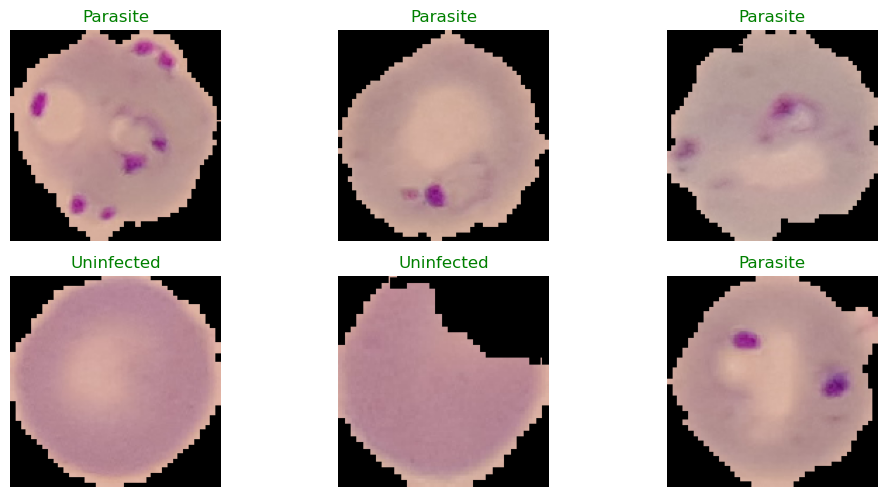

In [227]:
if INCLUDE_TEST:
    plot_prediction(test_generator, 6)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step


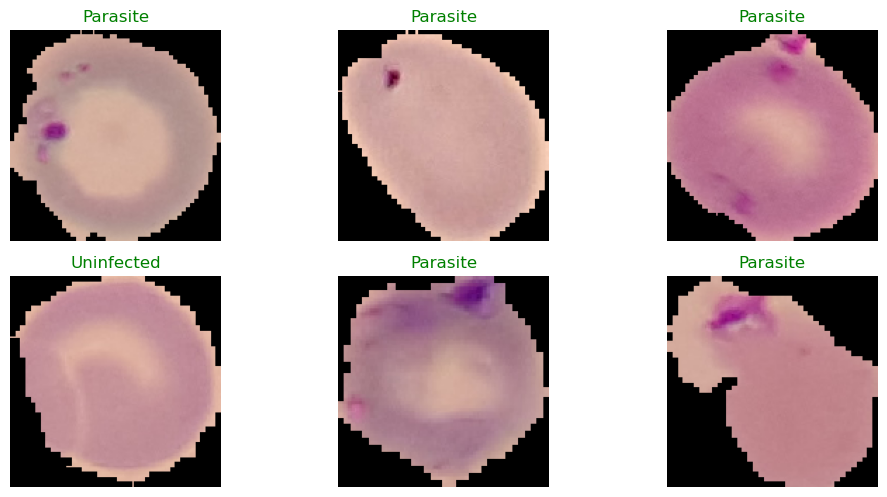

In [228]:
plot_prediction(validation_generator, 6)

<a name="4-3"></a>

## Visualize class activation maps

In [229]:
# Create a  model to visualize activation maps
gp_weights =  model.get_layer('dense_hidden').get_weights()[0]
activation_model = Model(model.inputs, outputs=(model.get_layer('conv6_256').output, model.get_layer('output_logits').output))

In [230]:
# Use the model to make predictions on the test generator
images, _ = next(test_generator)
features, results = activation_model.predict(images)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step


In [231]:
results

array([[9.98911858e-01, 1.08817185e-03],
       [1.00000000e+00, 7.22976366e-12],
       [1.07606038e-01, 8.92393887e-01],
       [9.74679515e-02, 9.02532101e-01],
       [9.96319413e-01, 3.68061033e-03],
       [1.00000000e+00, 2.37789338e-15],
       [1.00000000e+00, 1.56269569e-13],
       [1.30514771e-01, 8.69485319e-01],
       [1.00000000e+00, 2.08700150e-17],
       [1.08576082e-01, 8.91424000e-01],
       [1.21898539e-01, 8.78101468e-01],
       [9.99851346e-01, 1.48637933e-04],
       [1.00000000e+00, 4.46013398e-14],
       [8.44556019e-02, 9.15544391e-01],
       [1.99312583e-01, 8.00687492e-01],
       [1.00000000e+00, 1.23516676e-35],
       [1.00000000e+00, 1.03134610e-11],
       [1.39509231e-01, 8.60490799e-01],
       [1.00000000e+00, 4.10482321e-23],
       [9.90103036e-02, 9.00989711e-01],
       [9.82481763e-02, 9.01751876e-01],
       [1.00000000e+00, 3.21291984e-13],
       [1.00000000e+00, 6.39540288e-38],
       [9.99999404e-01, 6.17317994e-07],
       [1.211933

In [232]:
def show_cam(image_index, features, results):
    """
    Shows activation maps
    Args:
    image_index: index of image
    features: the extracted features
    results: model's predictions
    """
    # takes the features of the chosen image
    features_for_img = features[image_index,:,:,:]

    # get the class with the highest output probability
    prediction = np.argmax(results[image_index])

    # get the gap weights at the predicted class
    class_activation_weights = gp_weights[:,prediction]

    # upsample the features to the image's original size (150 x 150)
    class_activation_features = sp.ndimage.zoom(features_for_img, (150/30, 150/30, 1), order=2)

    # compute the intensity of each feature in the CAM
    cam_output  = np.dot(class_activation_features,class_activation_weights)

    print('Predicted Class = ' +str(class_names[prediction])+ ', Probability = ' + str(results[image_index][prediction]))

    # show the upsampled image
    
    plt.imshow(images[image_index])

    # strongly classified (95% probability) images will be in green, else red
    if results[image_index][prediction]>0.95:
        cmap_str = 'Greens'
    else:
        cmap_str = 'Blues'

    # overlay the cam output
    plt.imshow(cam_output, cmap=cmap_str, alpha=0.5)

    # display the image
    plt.show()

In [233]:
def show_maps(desired_class, num_maps):
    '''
    goes through the first 10,000 test images and generates Cam activation maps
    Args:
    desired_class: class to show the maps for
    num_maps: number of maps to be generated 
    '''
    counter = 0
    # go through the first 10000 images
    for i in range(0,10000):
        # break if we already displayed the specified number of maps
        if counter == num_maps:
            break

        # images that match the class will be shown
        if np.argmax(results[i]) == desired_class:
            counter += 1
            show_cam(i,features, results)

Predicted Class = Uninfected, Probability = 0.8923939


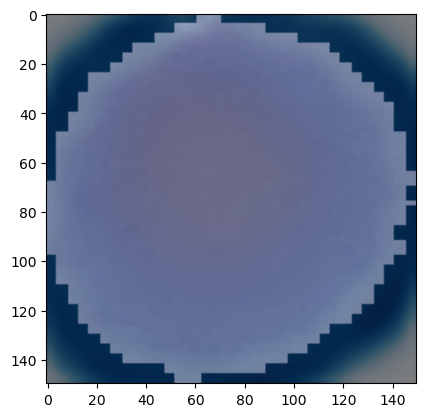

Predicted Class = Uninfected, Probability = 0.9025321


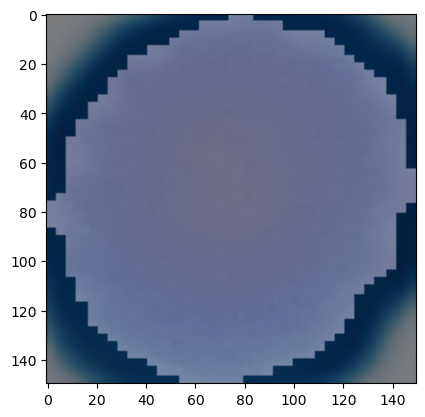

Predicted Class = Uninfected, Probability = 0.8694853


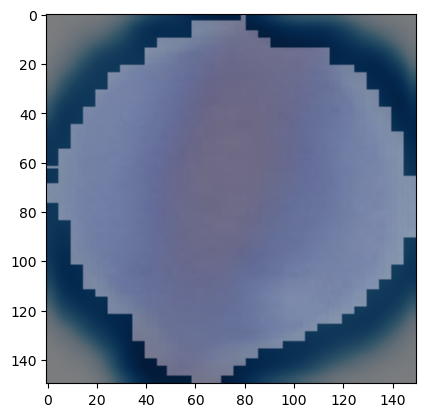

Predicted Class = Uninfected, Probability = 0.891424


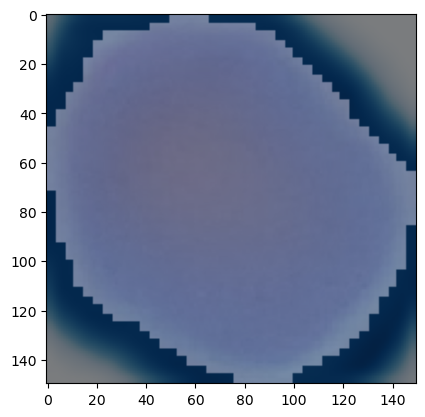

Predicted Class = Uninfected, Probability = 0.87810147


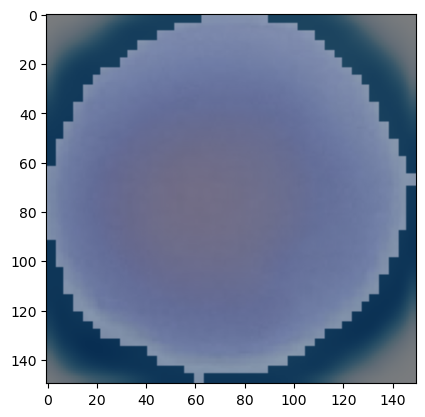

In [234]:
show_maps(desired_class=1, num_maps=5)

Predicted Class = Parasite, Probability = 0.99891186


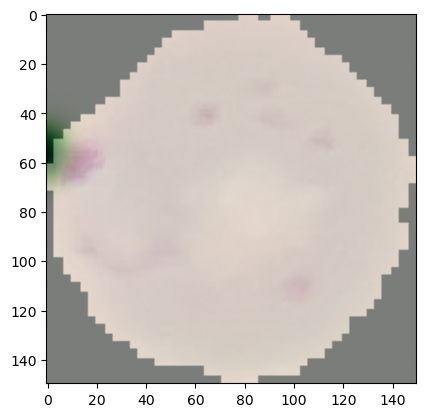

Predicted Class = Parasite, Probability = 1.0


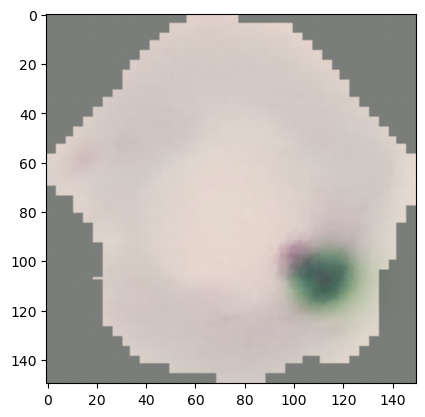

Predicted Class = Parasite, Probability = 0.9963194


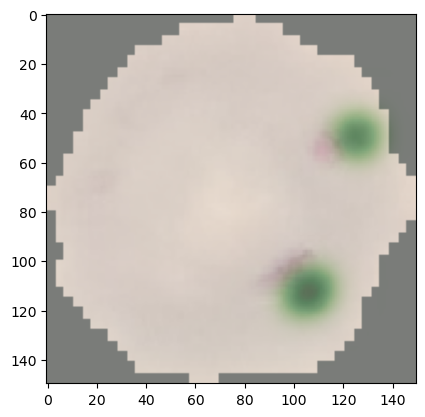

Predicted Class = Parasite, Probability = 1.0


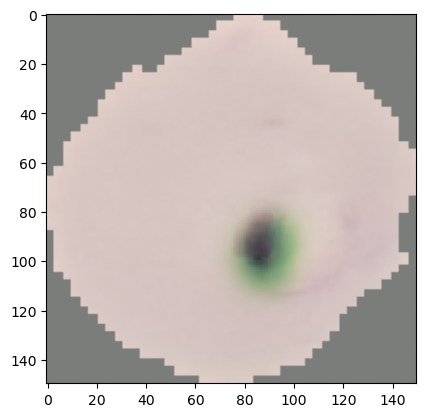

Predicted Class = Parasite, Probability = 1.0


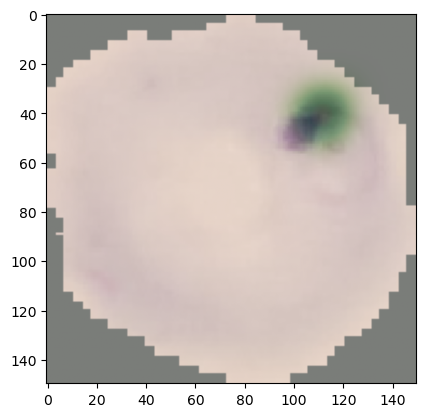

In [235]:
show_maps(desired_class=0, num_maps=5)

<a name="4-4"></a>

## Visualize training process

In [236]:
results = pd.DataFrame(r.history)
results.tail()

,accuracy,loss,val_accuracy,val_loss
15,0.930481,0.260033,0.857143,0.357221
16,0.903743,0.248558,0.904762,0.241201
17,0.927808,0.212218,1.000000,0.054549
18,0.933155,0.239794,0.880952,0.338219
19,0.922460,0.308520,0.880952,0.371320


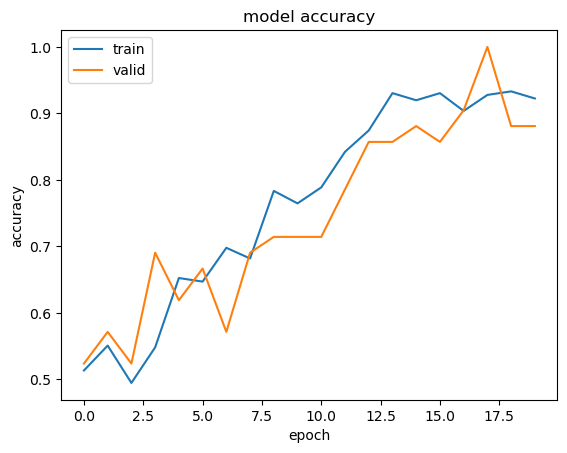

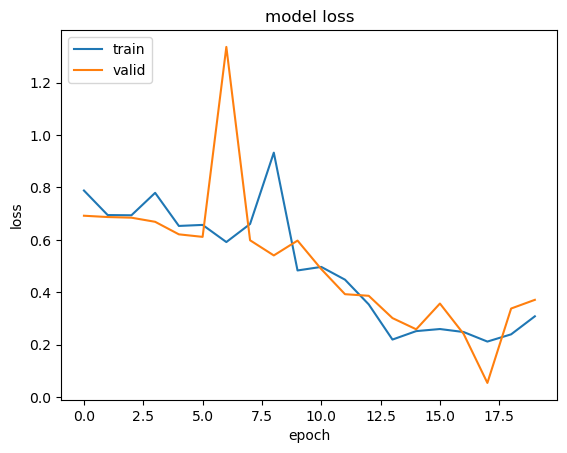

In [237]:
# summarize history for accuracy
plt.plot(results['accuracy'])
plt.plot(results['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'valid'], loc='upper left')
plt.show()
# summarize history for loss
plt.plot(results['loss'])
plt.plot(results['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'valid'], loc='upper left')
plt.show()



**Let's try using data augmentation**

<a id="5"></a>
<h1 style='background:#FFD700;border:0; color:black;
    box-shadow: 10px 10px 5px 0px rgba(0,0,0,0.75);
    transform: rotateX(10deg);
    '><center style='color: black;'>Trying Data Augmentation </center></h1>

# Trying Data Augmentation 

In [238]:
train_gen_aug = ImageDataGenerator(
        rescale=1./255,fill_mode='nearest',
    horizontal_flip=True,
        rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
)


validation_gen_aug =  ImageDataGenerator(
        rescale=1./255.)


In [239]:
train_generator = train_gen_aug.flow_from_directory(
        '/tmp/malaria/training',
        target_size=(150, 150),
        batch_size=16,
        class_mode='binary')
validation_generator = validation_gen_aug.flow_from_directory(
        '/tmp/malaria/validation',
        target_size=(150, 150),
        batch_size=16,
        class_mode='binary')

Found 374 images belonging to 2 classes.
Found 42 images belonging to 2 classes.


In [240]:
inputs = tf.keras.layers.Input(shape=(150,150,3))
x =  tf.keras.layers.Conv2D(32, (3,3), activation='relu')(inputs)
x = tf.keras.layers.Conv2D(64, (3,3), activation='relu')(x)
x = tf.keras.layers.MaxPooling2D(2,2)(x)

x = tf.keras.layers.Conv2D(64, (3,3), activation='relu')(x)
x = tf.keras.layers.Conv2D(128, (3,3), activation='relu')(x)
x = tf.keras.layers.MaxPooling2D(2,2)(x)

x = tf.keras.layers.Conv2D(128, (3,3), activation='relu')(x)
x = tf.keras.layers.Conv2D(256, (3,3), activation='relu')(x)
x = tf.keras.layers.MaxPooling2D(2,2)(x)

x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dense(20, activation='relu')(x) 
x = tf.keras.layers.Dense(2, activation='softmax')(x) 

model_aug = Model(inputs=inputs, outputs=x)

In [241]:
model_aug.summary()

Model: "functional_20"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_8 (InputLayer)      │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_26 (Conv2D)              │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_27 (Conv2D)              │ (None, 146, 146, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 73, 73, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_28 (Conv2D)              │ (None, 71, 71, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_29 (Conv2D)              │ (None, 69, 69, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 34, 34, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_30 (Conv2D)              │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_31 (Conv2D)              │ (None, 30, 30, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 15, 15, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 20)             │         5,140 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 2)              │            42 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 578,110 (2.21 MB)

 Trainable params: 578,110 (2.21 MB)

 Non-trainable params: 0 (0.00 B)

In [243]:
model_aug.compile(optimizer=tf.keras.optimizers.RMSprop(learning_rate=0.001),
              loss='sparse_categorical_crossentropy',
              metrics = ['accuracy'])

In [244]:
checkpoint_cb = tf.keras.callbacks.ModelCheckpoint("model_out/my_keras_model.h5", monitor='val_accuracy',
                             mode='max',
                             save_best_only=True,
                             verbose=1)

In [245]:
r = model_aug.fit(
        train_generator,
        epochs=20,#Training longer could yield better results
        validation_data=validation_generator, callbacks=[checkpoint_cb])

Epoch 1/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.5111 - loss: 0.6938
Epoch 1: val_accuracy improved from None to 0.52381, saving model to model_out/my_keras_model.h5



Epoch 1: finished saving model to model_out/my_keras_model.h5
24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 86ms/step - accuracy: 0.5267 - loss: 0.6928 - val_accuracy: 0.5238 - val_loss: 0.6930
Epoch 2/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.5346 - loss: 0.6980 
Epoch 2: val_accuracy did not improve from 0.52381
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 71ms/step - accuracy: 0.5294 - loss: 0.6997 - val_accuracy: 0.5238 - val_loss: 0.6897
Epoch 3/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.5442 - loss: 0.6902 
Epoch 3: val_accuracy did not improve from 0.52381
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 70ms/step - accuracy: 0.5775 - loss: 0.6876 - val_accuracy: 0.5238 - val_loss: 0.6949
Epoch 4/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.5535 - loss: 0.6849 
Epoch 4: val_accuracy improved from 0.52381 to 0.66667, saving model to model_out/my_keras_model.h5



Epoch 4: finished saving model to model_out/my_keras_model.h5
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 71ms/step - accuracy: 0.5722 - loss: 0.6852 - val_accuracy: 0.6667 - val_loss: 0.6279
Epoch 5/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.6017 - loss: 0.6769 
Epoch 5: val_accuracy did not improve from 0.66667
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 77ms/step - accuracy: 0.5642 - loss: 0.6767 - val_accuracy: 0.5238 - val_loss: 0.5734
Epoch 6/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.6327 - loss: 0.7403 
Epoch 6: val_accuracy improved from 0.66667 to 0.85714, saving model to model_out/my_keras_model.h5



Epoch 6: finished saving model to model_out/my_keras_model.h5
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 79ms/step - accuracy: 0.6952 - loss: 0.6384 - val_accuracy: 0.8571 - val_loss: 0.4740
Epoch 7/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 0.8874 - loss: 2.2554 
Epoch 7: val_accuracy did not improve from 0.85714
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 74ms/step - accuracy: 0.8797 - loss: 7.1693 - val_accuracy: 0.8571 - val_loss: 0.3244
Epoch 8/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.8767 - loss: 0.2753 
Epoch 8: val_accuracy improved from 0.85714 to 0.90476, saving model to model_out/my_keras_model.h5



Epoch 8: finished saving model to model_out/my_keras_model.h5
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 74ms/step - accuracy: 0.8770 - loss: 0.2663 - val_accuracy: 0.9048 - val_loss: 0.2732
Epoch 9/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.9336 - loss: 0.2138 
Epoch 9: val_accuracy improved from 0.90476 to 0.92857, saving model to model_out/my_keras_model.h5



Epoch 9: finished saving model to model_out/my_keras_model.h5
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 79ms/step - accuracy: 0.9037 - loss: 0.2480 - val_accuracy: 0.9286 - val_loss: 0.1865
Epoch 10/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 0.9288 - loss: 0.2064 
Epoch 10: val_accuracy improved from 0.92857 to 1.00000, saving model to model_out/my_keras_model.h5



Epoch 10: finished saving model to model_out/my_keras_model.h5
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 76ms/step - accuracy: 0.9332 - loss: 0.2078 - val_accuracy: 1.0000 - val_loss: 0.0977
Epoch 11/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.8839 - loss: 0.3080 
Epoch 11: val_accuracy did not improve from 1.00000
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 76ms/step - accuracy: 0.9091 - loss: 0.2757 - val_accuracy: 0.5238 - val_loss: 1.5634
Epoch 12/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.8781 - loss: 0.3461 
Epoch 12: val_accuracy did not improve from 1.00000
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 74ms/step - accuracy: 0.9037 - loss: 0.2681 - val_accuracy: 0.8333 - val_loss: 0.4241
Epoch 13/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.9147 - loss: 0.2568 
Epoch 13: val_accuracy did not improve from 1.00000
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 78ms/step - accuracy: 0.9064 - loss: 0.3384 - val_accuracy: 0.8333 - val_loss: 0.3827
Epoch 14/20
23/24 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - a

In [246]:
# Calling `save('my_model.keras')` creates a zip archive `my_model.keras`.
model_aug.save("model_out/cat_vs_dog_model_aug.keras")
model_aug_2 = tf.keras.models.load_model("model_out/my_keras_model.h5")
# It can be used to reconstruct the model identically.
#model_aug = keras.models.load_model("my_model.keras")

In [247]:
results = pd.DataFrame(r.history)
results.tail()

,accuracy,loss,val_accuracy,val_loss
15,0.943850,0.180354,0.880952,0.321528
16,0.922460,0.240662,1.000000,0.029201
17,0.951872,0.175006,1.000000,0.036196
18,0.951872,0.169989,1.000000,0.043700
19,0.930481,0.243482,0.880952,0.309548


In [248]:
results

,accuracy,loss,val_accuracy,val_loss
0,0.526738,0.692824,0.523810,0.692985
1,0.529412,0.699732,0.523810,0.689685
2,0.577540,0.687609,0.523810,0.694904
3,0.572192,0.685221,0.666667,0.627920
4,0.564171,0.676715,0.523810,0.573447
5,0.695187,0.638379,0.857143,0.474003
6,0.879679,7.169251,0.857143,0.324437
7,0.877005,0.266337,0.904762,0.273153
8,0.903743,0.247995,0.928571,0.186487
9,0.933155,0.207822,1.000000,0.097737


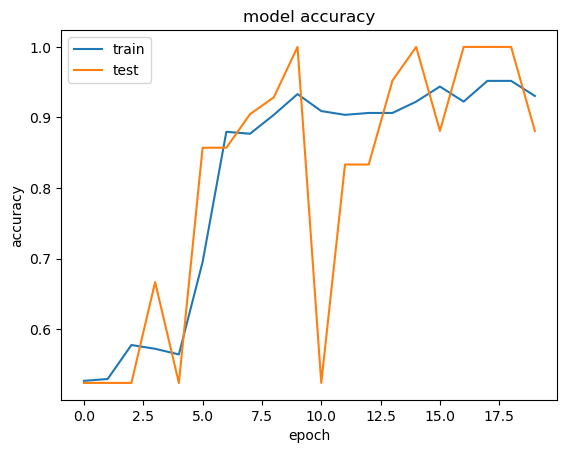

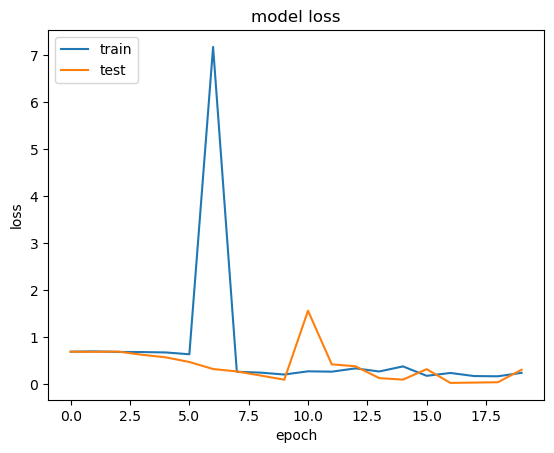

In [249]:
# summarize history for accuracy
plt.plot(results['accuracy'])
plt.plot(results['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()
# summarize history for loss
plt.plot(results['loss'])
plt.plot(results['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

Evaluate augmentation model

In [250]:
if INCLUDE_TEST:
    model_aug.evaluate(test_generator)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.8657 - loss: 0.2961 


In [251]:
if INCLUDE_TEST:
    model_aug_2.evaluate(test_generator)

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.9104 - loss: 0.1989 


<a id="5"></a>
<h1 style='background:#FFD700;border:0; color:black;
    box-shadow: 10px 10px 5px 0px rgba(0,0,0,0.75);
    transform: rotateX(10deg);
    '><center style='color: black;'>Cat vs Dog Classifier Using Transfer Learning Xception PreTrained Mode </center></h1>
 

![](https://miro.medium.com/v2/resize:fit:640/format:webp/1*459jKxLPM9R-Y_z0y8SXug.png)

![](https://miro.medium.com/v2/resize:fit:786/format:webp/1*tCTo6M1E5rZ4_ARnPcv-gQ.png)

In [252]:
#PreTrained Model VGG16
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications import Xception
from keras import Sequential
from keras import layers

class CustomMaskLayer(layers.Layer):
    def __init__(self, **kwargs):
        super(CustomMaskLayer, self).__init__(**kwargs)
        # Inicializuok savo sluoksnio parametrus čia

    def call(self, inputs):
        # Tavo sluoksnio logika čia
        return inputs

    def get_config(self):
        # Grąžink visus parametrus, kuriuos reikia išsaugoti ir vėl užkrauti
        config = super(CustomMaskLayer, self).get_config()
        return config

In [253]:
train_generator = train_gen_aug.flow_from_directory(
        '/tmp/malaria/training',
        target_size=(150, 150),
        batch_size=32,
        class_mode='binary')
validation_generator = validation_gen_aug.flow_from_directory(
        '/tmp/malaria/validation',
        target_size=(150, 150),
        batch_size=32,
        class_mode='binary')
test_generator = test_gen.flow_from_directory(
        '/tmp/malaria/test',
        target_size=(150, 150),
        batch_size=32,
        class_mode='binary')

Found 374 images belonging to 2 classes.
Found 42 images belonging to 2 classes.
Found 134 images belonging to 2 classes.


In [254]:
# Load the pre-trained Xception model without the top (classification) layer
xception_base = Xception(weights='imagenet', include_top=False, input_shape=(150, 150, 3))
xception_base.trainable = False

In [255]:
# Build the model
model_x = Sequential()

# Add the pre-trained Xception base
model_x.add(xception_base)

# Add global average pooling layer to reduce spatial dimensions
model_x.add(AveragePooling2D(pool_size=(2, 2)))

# Flatten the feature maps
model_x.add(Flatten())

# Add a dense layer with 220 units and ReLU activation function
model_x.add(Dense(20, activation='relu'))

# Add the output layer with 2 unit and sigmoid activation function for binary classification
model_x.add(Dense(2, activation='sigmoid'))

In [256]:
#Complie
model_x.compile(optimizer = tf.keras.optimizers.RMSprop(learning_rate=0.0001, rho=0.9),
                loss='sparse_categorical_crossentropy',
              metrics = ['accuracy'])

In [257]:
r = model_x.fit(
        train_generator,
        epochs=5,
        validation_data=validation_generator)

Epoch 1/5
12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 244ms/step - accuracy: 0.7032 - loss: 0.5581 - val_accuracy: 0.8571 - val_loss: 0.3812
Epoch 2/5
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 167ms/step - accuracy: 0.8476 - loss: 0.3610 - val_accuracy: 0.9048 - val_loss: 0.2904
Epoch 3/5
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 169ms/step - accuracy: 0.9091 - loss: 0.2745 - val_accuracy: 0.9048 - val_loss: 0.2472
Epoch 4/5
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 174ms/step - accuracy: 0.9091 - loss: 0.2474 - val_accuracy: 0.9048 - val_loss: 0.1977
Epoch 5/5
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 171ms/step - accuracy: 0.9118 - loss: 0.2071 - val_accuracy: 0.9048 - val_loss: 0.1911


In [258]:
# Calling `save('my_model.keras')` creates a zip archive `my_model.keras`.
#model_x.save("cat_vs_dog_model_x.keras")
#model_x2 = tf.keras.models.load_model("/kaggle/working/my_x_keras_model.h5", custom_objects={'CustomMaskLayer': CustomMaskLayer, 'Xception': xception_base}, , compile=False)
# It can be used to reconstruct the model identically.


In [259]:
if INCLUDE_TEST:
    model_x.evaluate(test_generator)

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 114ms/step - accuracy: 0.9328 - loss: 0.1962


In [260]:
from skimage import io
import cv2
#image = io.imread('https://www.vle.lt/uploads/_CGSmartImage/114292_1-1608eda0d9c54043ad61ed96f6239ef6.jpg')
image = io.imread('https://s1.15min.lt/static/cache/OTcweDU4MCwzODJ4NDg3LDcxNTcyOCxvcmlnaW5hbCwsaWQ9MzExODMwOCZkYXRlPTIwMTclMkYwNiUyRjA5LDM2MjEwNTE5ODM=/juoda-veido-kauke-593a88d641962.jpg')
img = cv2.resize(image, (150, 150))
    # Normalize pixel values
img_array = img.astype(np.float32) / 255.0  

    # Expand the dimensions to match the input shape expected by the model
img_array = np.expand_dims(img_array, axis=0)

    # Make predictions
predictions = model_x.predict(img_array)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 703ms/step


In [261]:
predictions[0][1]

0.085503235

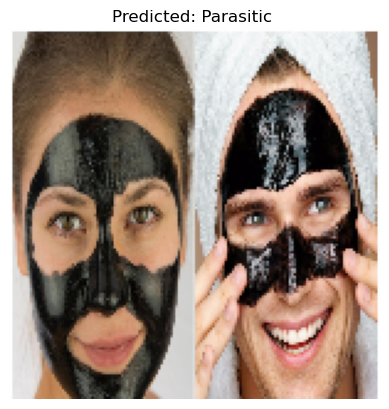

In [262]:
    actual_prediction = (predictions[0][0] > predictions[0][1]).astype(int)

    # Display the image with true and predicted labels
    # Convert BGR to RGB for displaying with matplotlib
    plt.imshow(img)  
    plt.axis('off')
    if actual_prediction == 1:
        predicted_label = 'Parasitic'
    else:
        predicted_label = 'Uninfected'
    plt.title(f'Predicted: {predicted_label} ')
    plt.show()

<a id="5"></a>
<h1 style='background:#FFD700;border:0; color:black;
    box-shadow: 10px 10px 5px 0px rgba(0,0,0,0.75);
    transform: rotateX(10deg);
    '><center style='color: black;'>Conclusion </center></h1>

# Conclusion 

**Using data augmentation with these hyper-parameters gave us worse results**


**We can Use [transfer learning](https://www.kaggle.com/code/fareselmenshawii/introdution-to-transfer-learning/edit/run/109466477) or a more complex architecture to solve this problem**

**We'll discuss these topics in later notebooks**

<a id="7"></a>
<h1 style='background:#FFD700;border:0; color:black;
    box-shadow: 10px 10px 5px 0px rgba(0,0,0,0.75);
    transform: rotateX(10deg);
    '><center style='color: black;'>Thank You </center></h1>


    
# Thank You

**Thank you for taking your time and going through this notebook**

**Please let me know if you have any feedback**